<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Face_Search_Uniface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q "uniface[cpu]"

# Clone repo for assets (Colab / Kaggle only)
import os
if any(k in os.environ for k in ('COLAB_GPU', 'COLAB_RELEASE_TAG', 'KAGGLE_KERNEL_RUN_TYPE')):
    if not os.path.exists('uniface'):
        !git clone --depth 1 https://github.com/yakhyo/uniface.git
    os.chdir('uniface/examples')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.8 MB/s eta 0:00:00
Cloning into 'uniface'...
remote: Enumerating objects: 287, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (279/279), done.
remote: Total 287 (delta 38), reused 116 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (287/287), 23.29 MiB | 25.73 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [2]:
import cv2
import matplotlib.pyplot as plt

import uniface
from uniface.analyzer import FaceAnalyzer
from uniface.detection import RetinaFace
from uniface.recognition import ArcFace

print(uniface.__version__)

4.0.0



`FaceAnalyzer` bundles the detector and the recognizer, so one `analyze()` call
returns faces that already carry embeddings.


In [3]:
analyzer = FaceAnalyzer(
    detector=RetinaFace(confidence_threshold=0.5),
    recognizer=ArcFace()
)

Attempt 1/3: 100%|██████████| 11.9M/11.9M [00:00<00:00, 96.0MB/s]
Attempt 1/3: 100%|██████████| 13.0M/13.0M [00:00<00:00, 93.9MB/s]


## 1. Embed the Face We Are Looking For

The query only needs embedding once. Everything after this is a comparison against it.

In [4]:
# Load Einstein's photo
einstein_path = '../assets/source/verify_einstein_1947.jpg'
einstein_image = cv2.imread(einstein_path)

# Get Einstein's face features
einstein_faces = analyzer.analyze(einstein_image)

if einstein_faces:
    einstein_face = einstein_faces[0]
    print(f'Detected {len(einstein_faces)} face with {einstein_face.embedding.shape[0]}D features')


Detected 1 face with 512D features


## 2. Find Every Face in the Group Photo

The same call on the group photo gives one embedding per person.

In [5]:
# Load the group photo
group_photo_path = '../assets/source/detect_crowd.jpg'
group_photo = cv2.imread(group_photo_path)

# Find all faces in the group photo
group_faces = analyzer.analyze(group_photo)
print(f'Detected {len(group_faces)} people in the group photo')

Detected 29 people in the group photo


## 3. Look at Both Inputs

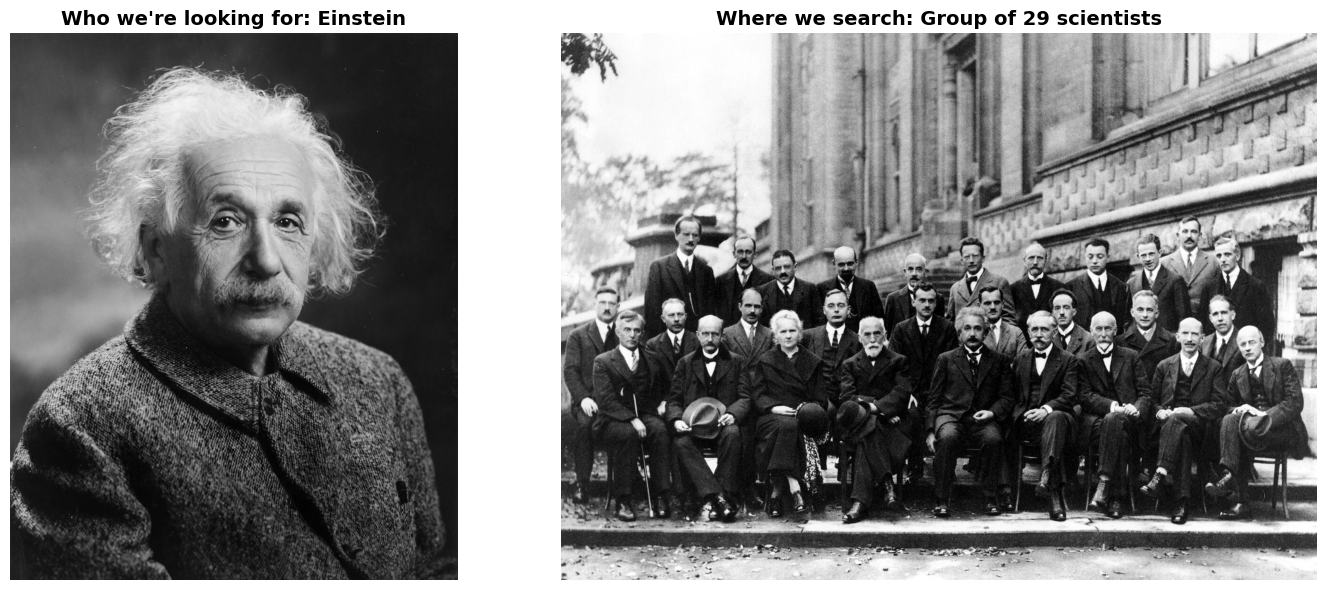

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display Einstein's photo
axes[0].imshow(cv2.cvtColor(einstein_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Who we're looking for: Einstein", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Display the group photo
axes[1].imshow(cv2.cvtColor(group_photo, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Where we search: Group of {len(group_faces)} scientists', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Compare and Rank

`compute_similarity()` is a dot product between two normalised embeddings, so it is the
cosine similarity. Sorting descending puts the likeliest person first.

In [7]:
if not einstein_faces or not group_faces:
    print('Error: Could not detect faces')
else:
    # Compare Einstein with each person in the group
    matches = []
    for i, person in enumerate(group_faces):
        similarity = einstein_face.compute_similarity(person)
        matches.append((i, similarity))

    # Sort by similarity (best matches first)
    matches.sort(key=lambda x: x[1], reverse=True)

    # Show top 5 matches
    print('Top 5 most similar people:')
    for rank, (person_idx, similarity) in enumerate(matches[:5], 1):
        print(f'{rank}. Person #{person_idx + 1}: similarity = {similarity:.4f}')


Top 5 most similar people:
1. Person #10: similarity = 0.5790
2. Person #17: similarity = 0.1808
3. Person #25: similarity = 0.1609
4. Person #15: similarity = 0.1564
5. Person #28: similarity = 0.1480


## 5. Mark the Winner

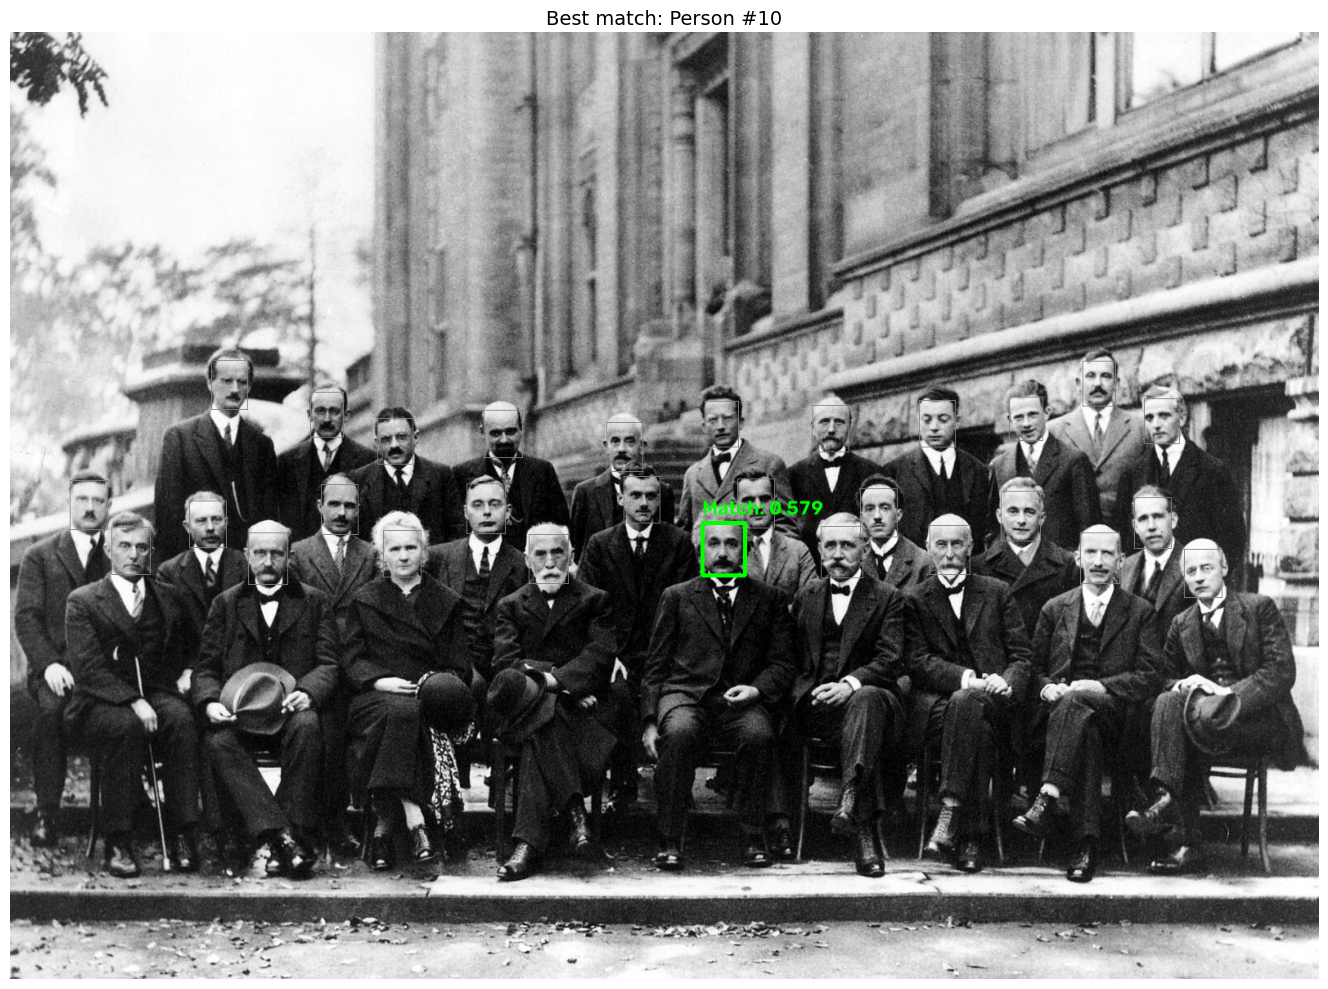

In [8]:
if einstein_faces and group_faces:
    # Get the best match
    best_match_idx, best_similarity = matches[0]

    # Draw bounding boxes
    result_image = group_photo.copy()

    for i, person in enumerate(group_faces):
        bbox = person.bbox.astype(int)

        if i == best_match_idx:
            color = (0, 255, 0)
            thickness = 3
        else:
            color = (128, 128, 128)
            thickness = 1

        cv2.rectangle(result_image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, thickness)

        if i == best_match_idx:
            label = f'Match: {best_similarity:.3f}'
            cv2.putText(result_image, label, (bbox[0], bbox[1] - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Best match: Person #{best_match_idx + 1}', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## 6. Inspect the Top Three

Seeing the runners-up is how you tell a confident match from a lucky one.

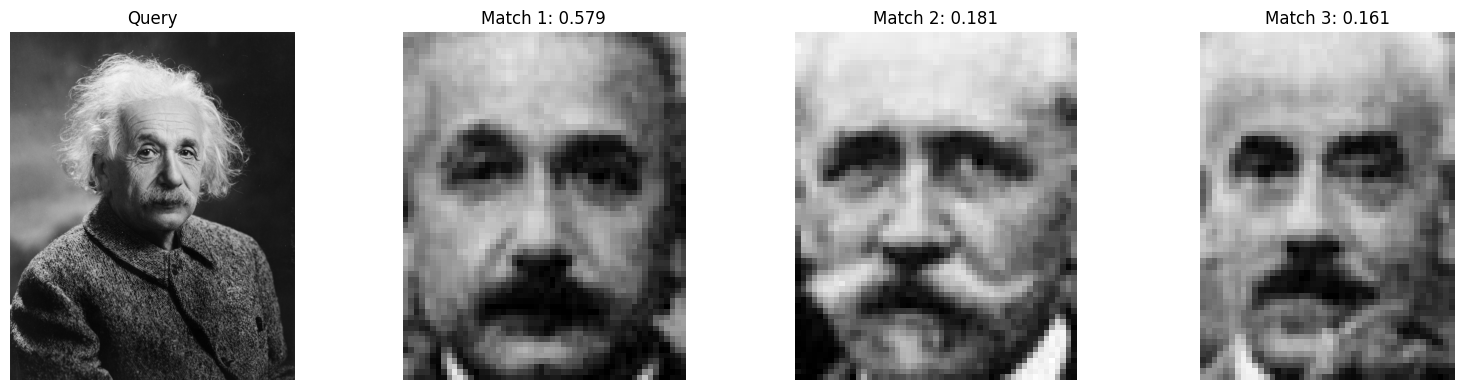

In [9]:
if einstein_faces and group_faces:
    # Show top 3 matches
    top_k = min(3, len(matches))

    fig, axes = plt.subplots(1, top_k + 1, figsize=(16, 4))

    # Show Einstein's face
    einstein_rgb = cv2.cvtColor(einstein_image, cv2.COLOR_BGR2RGB)
    axes[0].imshow(einstein_rgb)
    axes[0].set_title("Query", fontsize=12)
    axes[0].axis('off')

    # Show top 3 matches from the group
    for i, (person_idx, similarity) in enumerate(matches[:top_k]):
        person = group_faces[person_idx]
        bbox = person.bbox.astype(int)

        # Crop this person's face
        face_crop = group_photo[bbox[1]:bbox[3], bbox[0]:bbox[2]]

        if face_crop.size > 0:
            face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
            axes[i + 1].imshow(face_rgb)
            axes[i + 1].set_title(f'Match {i + 1}: {similarity:.3f}', fontsize=12)
            axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()


## 7. Decide With a Threshold

Ranking alone always returns a best match, even when the person is absent. A threshold is
what turns the ranking into a yes or no answer.

In [10]:
# 0.4 is the library default, the value FAISS.search uses
THRESHOLD = 0.4

if einstein_faces and group_faces:
    best_match_idx, best_similarity = matches[0]

    print(f'Best match: Person #{best_match_idx + 1}')
    print(f'Similarity: {best_similarity:.4f}')
    print(f'Threshold: {THRESHOLD}')

    if best_similarity > THRESHOLD:
        print(f'Result: Match found (Einstein is person #{best_match_idx + 1})')
    else:
        print(f'Result: No match (similarity below threshold)')


Best match: Person #10
Similarity: 0.5790
Threshold: 0.4
Result: Match found (Einstein is person #10)


## Notes

- Ranking always produces a best match, including when the person is absent. The threshold is
  what turns a ranking into a yes or no.
- Past a few hundred faces, replace this loop with an index. Notebook 10 shows that.


--- Realizando una nueva comparación de imágenes ---
Detectada 1 cara en la primera imagen con 512D características.
Detectada 1 cara en la segunda imagen con 512D características.

Similitud entre las dos caras: 0.4652
Umbral de comparación: 0.4
Resultado: Es probable que las caras pertenezcan a la misma persona.


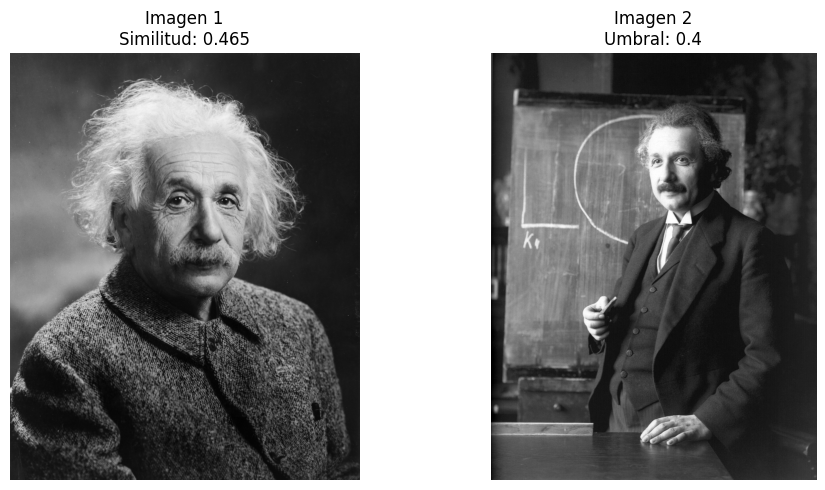

In [17]:
print("\n--- Realizando una nueva comparación de imágenes ---")

# Rutas a las dos imágenes a comparar
image1_path = '../assets/source/verify_einstein_1947.jpg'
image2_path = '../assets/source/verify_einstein_1921.jpg'

# Cargar las imágenes
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)

# Verificar si las imágenes se cargaron correctamente
if image1 is None:
    print(f"Error: No se pudo cargar la imagen desde {image1_path}. Verifica la ruta.")
elif image2 is None:
    print(f"Error: No se pudo cargar la imagen desde {image2_path}. Verifica la ruta.")
else:
    # Analizar las caras en ambas imágenes
    faces1 = analyzer.analyze(image1)
    faces2 = analyzer.analyze(image2)

    face1 = None
    if faces1:
        face1 = faces1[0]
        print(f'Detectada 1 cara en la primera imagen con {face1.embedding.shape[0]}D características.')
    else:
        print(f'Error: No se detectó ninguna cara en la primera imagen ({image1_path}).')

    face2 = None
    if faces2:
        face2 = faces2[0]
        print(f'Detectada 1 cara en la segunda imagen con {face2.embedding.shape[0]}D características.')
    else:
        print(f'Error: No se detectó ninguna cara en la segunda imagen ({image2_path}).')

    if face1 and face2:
        # Comparar las características de las caras
        similarity = face1.compute_similarity(face2)

        print(f'\nSimilitud entre las dos caras: {similarity:.4f}')
        print(f'Umbral de comparación: {THRESHOLD}') # Reutilizando el umbral definido anteriormente

        if similarity > THRESHOLD:
            print('Resultado: Es probable que las caras pertenezcan a la misma persona.')
        else:
            print('Resultado: Es probable que las caras pertenezcan a personas diferentes.')

        # Visualizar las dos caras con la similitud
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Mostrar la primera imagen y su resultado
        axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Imagen 1\nSimilitud: {similarity:.3f}", fontsize=12)
        axes[0].axis('off')

        # Mostrar la segunda imagen y su resultado
        axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Imagen 2\nUmbral: {THRESHOLD}", fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No se puede comparar, una o ambas caras no fueron detectadas.")


--- Realizando una nueva comparación de imágenes ---
Detectada 1 cara en la primera imagen con 512D características.
Detectada 1 cara en la segunda imagen con 512D características.

Similitud entre las dos caras: 0.6122
Umbral de comparación: 0.4
Resultado: Es probable que las caras pertenezcan a la misma persona.


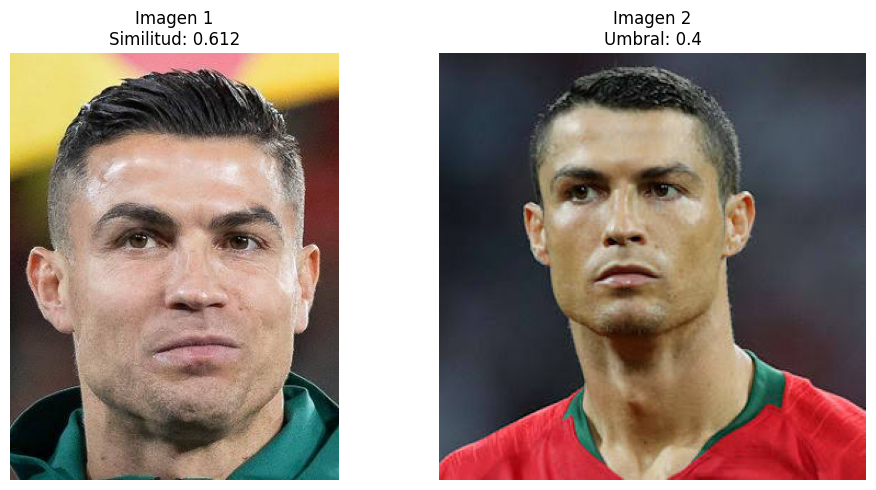

In [20]:
print('\n--- Realizando una nueva comparación de imágenes ---')

# Rutas a las dos imágenes a comparar
# Asegúrate de que estas rutas sean correctas y existan en tu entorno
# Por ejemplo, si subiste 'cristiano_ronaldo_1.jpg' y 'cristiano_ronaldo_2.jpg'
# a la carpeta 'assets/source', las rutas serían:
image1_path = '/content/cristiano_ronaldo_1.jpg'
image2_path = '/content/cristiano_ronaldo_2.jpg'

# Cargar las imágenes
image1 = cv2.imread(image1_path)
image2 = cv2.imread(image2_path)

# Verificar si las imágenes se cargaron correctamente
if image1 is None:
    print(f"Error: No se pudo cargar la imagen desde {image1_path}. Verifica la ruta.")
elif image2 is None:
    print(f"Error: No se pudo cargar la imagen desde {image2_path}. Verifica la ruta.")
else:
    # Analizar las caras en ambas imágenes
    faces1 = analyzer.analyze(image1)
    faces2 = analyzer.analyze(image2)

    face1 = None
    if faces1:
        face1 = faces1[0]
        print(f'Detectada 1 cara en la primera imagen con {face1.embedding.shape[0]}D características.')
    else:
        print(f'Error: No se detectó ninguna cara en la primera imagen ({image1_path}).')

    face2 = None
    if faces2:
        face2 = faces2[0]
        print(f'Detectada 1 cara en la segunda imagen con {face2.embedding.shape[0]}D características.')
    else:
        print(f'Error: No se detectó ninguna cara en la segunda imagen ({image2_path}).')

    if face1 and face2:
        # Comparar las características de las caras
        similarity = face1.compute_similarity(face2)

        print(f'\nSimilitud entre las dos caras: {similarity:.4f}')
        print(f'Umbral de comparación: {THRESHOLD}') # Reutilizando el umbral definido anteriormente

        if similarity > THRESHOLD:
            print('Resultado: Es probable que las caras pertenezcan a la misma persona.')
        else:
            print('Resultado: Es probable que las caras pertenezcan a personas diferentes.')

        # Visualizar las dos caras con la similitud
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Mostrar la primera imagen y su resultado
        axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Imagen 1\nSimilitud: {similarity:.3f}", fontsize=12)
        axes[0].axis('off')

        # Mostrar la segunda imagen y su resultado
        axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Imagen 2\nUmbral: {THRESHOLD}", fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No se puede comparar, una o ambas caras no fueron detectadas.")

In [24]:
group_photo_path = '/content/equipo.jpg'
group_photo = cv2.imread(group_photo_path)

# Find all faces in the group photo
group_faces = analyzer.analyze(group_photo)
print(f'Detected {len(group_faces)} people in the group photo')

Detected 11 people in the group photo


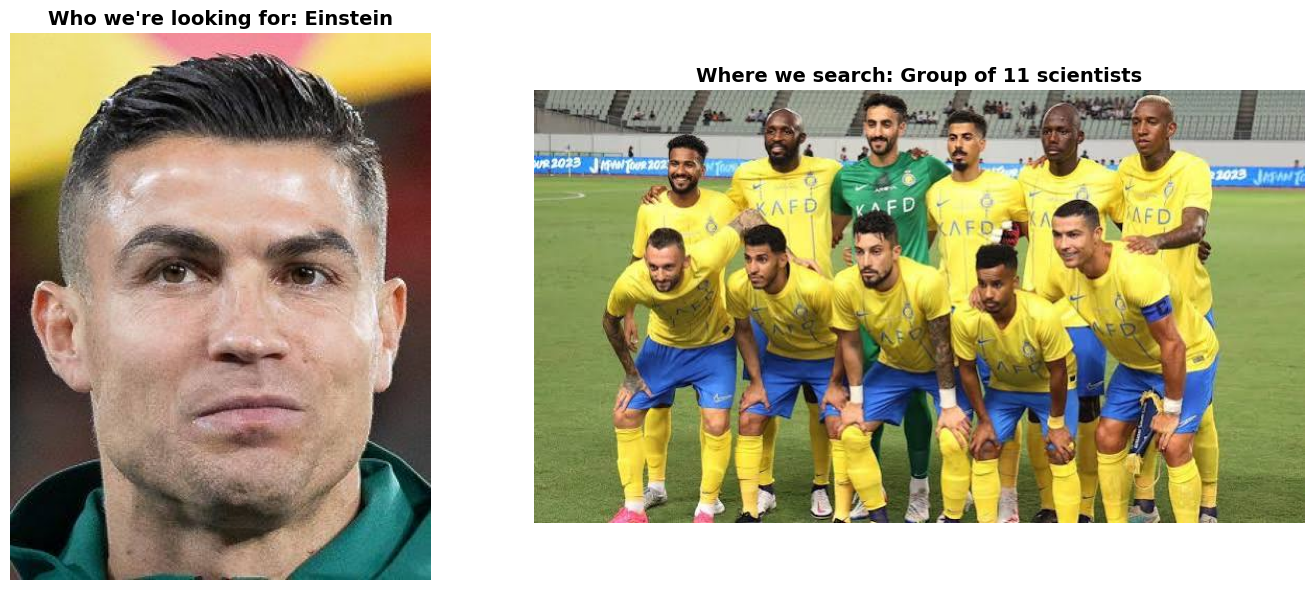

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display Einstein's photo
axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Who we're looking for: Einstein", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Display the group photo
axes[1].imshow(cv2.cvtColor(group_photo, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Where we search: Group of {len(group_faces)} scientists', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
if faces1:
    face = faces1[0]
    print(f'Detected {len(faces1)} face with {face.embedding.shape[0]}D features')

Detected 1 face with 512D features


In [28]:
if not faces1 or not group_faces:
    print('Error: Could not detect faces')
else:
    # Compare Einstein with each person in the group
    matches = []
    for i, person in enumerate(group_faces):
        similarity = face.compute_similarity(person)
        matches.append((i, similarity))

    # Sort by similarity (best matches first)
    matches.sort(key=lambda x: x[1], reverse=True)

    # Show top 5 matches
    print('Top 5 most similar people:')
    for rank, (person_idx, similarity) in enumerate(matches[:5], 1):
        print(f'{rank}. Person #{person_idx + 1}: similarity = {similarity:.4f}')

Top 5 most similar people:
1. Person #1: similarity = 0.4715
2. Person #4: similarity = 0.1215
3. Person #3: similarity = 0.0653
4. Person #11: similarity = 0.0564
5. Person #10: similarity = 0.0341


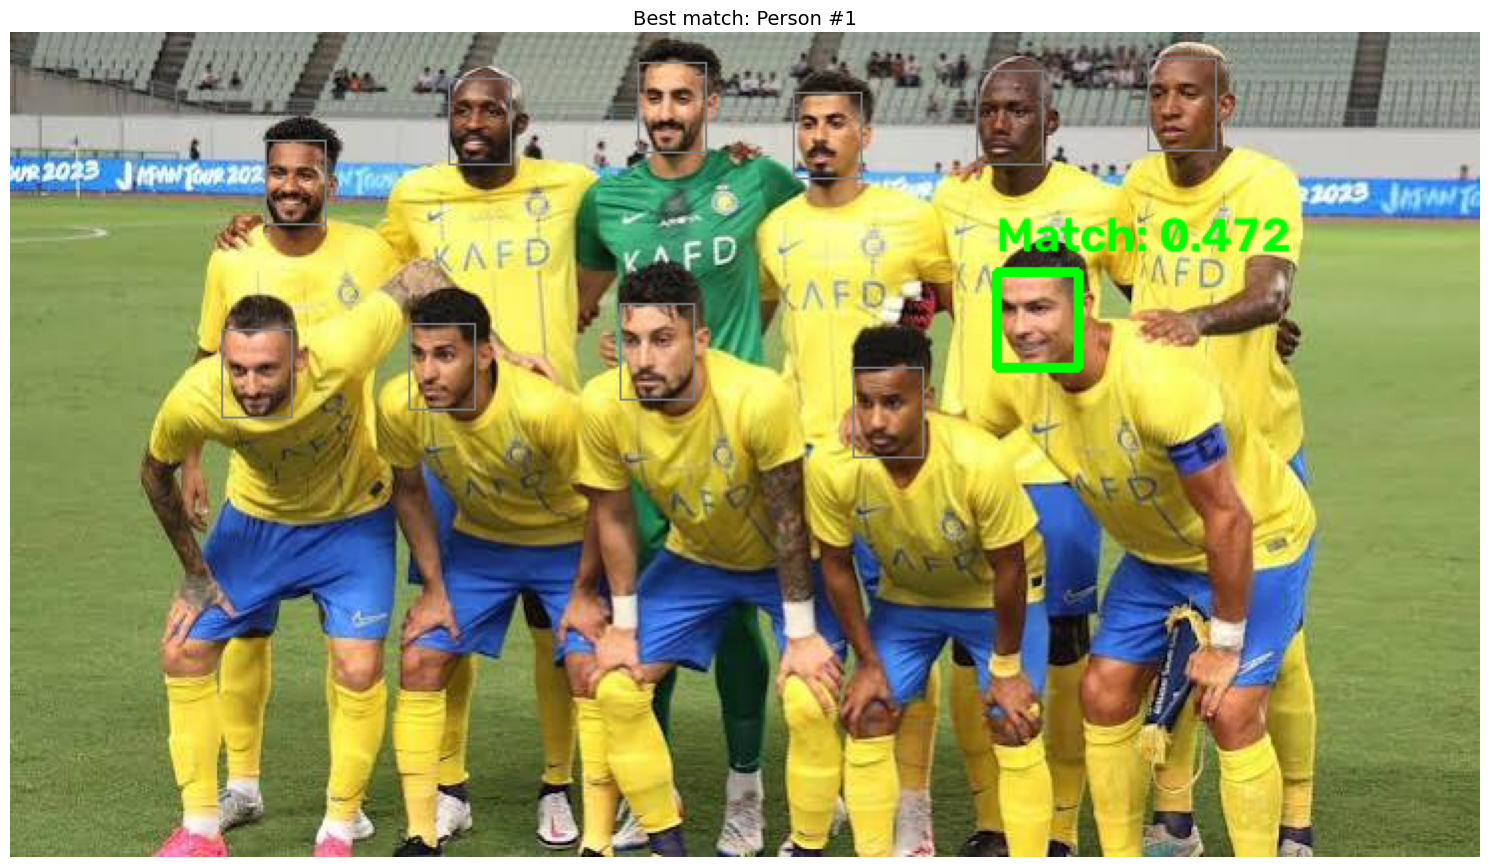

In [29]:
if faces1 and group_faces:
    # Get the best match
    best_match_idx, best_similarity = matches[0]

    # Draw bounding boxes
    result_image = group_photo.copy()

    for i, person in enumerate(group_faces):
        bbox = person.bbox.astype(int)

        if i == best_match_idx:
            color = (0, 255, 0)
            thickness = 3
        else:
            color = (128, 128, 128)
            thickness = 1

        cv2.rectangle(result_image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, thickness)

        if i == best_match_idx:
            label = f'Match: {best_similarity:.3f}'
            cv2.putText(result_image, label, (bbox[0], bbox[1] - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Best match: Person #{best_match_idx + 1}', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()